In [1]:
# Rubriks voor het notebook:
# Data handling 10%
# Visualisation and DAG 10%
# Correlation matrix and conclusions 10%
# Data prep for modelling 15%
# Algoritms and Models 10%
# Metrics and prediction 10%
# Markdown 15%
# Structure 10%
# Code 10%

# Algemeen

In [2]:
# Dataframe check-in tijden: df_checkin
# Dataframe cardholders: df_cardholders
# Dataframe ACLO Card houders met daarin fitness abonnementen: df_ACLO_card

In [99]:
# Importeren benodigde libraries
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx
from pathlib import Path
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import explained_variance_score
from sklearn import preprocessing
from scipy import stats
from scipy.stats import chi2_contingency

In [4]:
# CSV files inladen
df_CI_2017 = pd.read_csv('Check-in times\Check-in-times_sheet_2017-2018.csv', decimal='.')
df_CI_2018 = pd.read_csv('Check-in times\Check-in-times_sheet_2018-2019.csv', decimal='.')
df_CI_2019 = pd.read_csv('Check-in times\Check-in-times_sheet_2019-2020.csv', decimal='.')
df_CI_2020 = pd.read_csv('Check-in times\Check-in-times_sheet_2020-2021.csv', decimal='.')
df_CI_2021 = pd.read_csv('Check-in times\Check-in-times_sheet_2021- .csv', decimal='.')

df_MA_2020 = pd.read_csv('Cardholders\Membership Aclo_sheet_ACLO  2020-2021.csv', decimal='.')
df_MA_2021 = pd.read_csv('Cardholders\Membership Aclo_sheet_ACLO 2021-2022.csv', decimal='.')
df_MF_2020 = pd.read_csv('Cardholders\Membership Aclo_sheet_Fitness  2020-2021.csv', decimal='.')
df_MF_2021 = pd.read_csv('Cardholders\Membership Aclo_sheet_Fitness 2021-2022 .csv', decimal='.')

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
<>:6: SyntaxWarning: invalid escape sequence '\C'
<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
<>:10: SyntaxWarning: invalid escape sequence '\M'
<>:11: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
<>:6: SyntaxWarning: invalid escape sequence '\C'
<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
<>:10: SyntaxWarning: invalid escape sequence '\M'
<>:11: SyntaxWarning: invalid escape sequence '\M'
C:\Users\betti\AppData\Local\Temp\ipykernel_12388\541146343.py:2: SyntaxWarning: invalid escape 

# Data cleaning en verkenning van de data

## Check-in tijden

In [5]:
# Hebben alle dataframes dezelfde kolommen?
df_CI_2017.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,168236,Medewerker RUG,M,Fitness Card 2016-2017,2017-08-01 12:49:10
1,132339,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:11
2,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:34
3,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:54:13
4,186817,RUG,M,Fitness Card 2016-2017,2017-08-01 13:00:58


In [6]:
# In deze 'head' staan 2 regels voor klant 141170. Deze bezoeker is 2x ingecheckt binnen 1 minuut. -> Dit beschouwen als een dubbele regel? Meerdere van dit soort regels in de data?

In [7]:
df_CI_2018.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,117879,Medewerker RUG/Hanze,M,Fitness Card 2017-2018,2018-08-01 12:48:52
1,146660,Medewerker RUG/Hanze,M,Fitness Card 2017-2018,2018-08-01 12:49:03
2,173963,Medewerker RUG/Hanze,M,Fitness Card 2017-2018,2018-08-01 12:54:52
3,185667,RUG,M,Fitness Card 2017-2018,2018-08-01 13:01:46
4,180476,Medewerker RUG/Hanze,M,Fitness Card 2017-2018,2018-08-01 13:03:11


In [8]:
df_CI_2019.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,194261,RUG,M,Fitness 2nd semester Card 18-19,2019-08-02 12:48:58
1,186218,Hanze,M,Fitness Card 2018-2019,2019-08-02 12:50:31
2,186218,Hanze,M,Fitness Card 2018-2019,2019-08-02 12:50:35
3,202793,Hanze,M,Fitness Card 2018-2019,2019-08-02 12:51:29
4,114664,Medewerkers RUG/Hanze,M,SPR sportcard Incasso,2019-08-02 12:52:06


In [9]:
df_CI_2020.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,204257,RUG,M,Fitness Card 2019-2020,2020-08-03 12:49:25
1,185550,Hanze,M,Fitness Card 2019-2020,2020-08-03 12:59:43
2,214192,RUG,M,Fitness Card 2019-2020,2020-08-03 14:16:11
3,172702,Hanze,M,Fitness Card 2019-2020,2020-08-03 14:16:22
4,202597,NaN,fout,NaN,2020-08-03 14:18:39


In [10]:
df_CI_2021.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,189865,RUG,M,NaN,2021-08-02 13:00:10
1,223378,RUG,V,NaN,2021-08-02 13:00:15
2,220941,RUG,M,NaN,2021-08-02 13:00:20
3,159667,RUG,M,NaN,2021-08-02 13:00:27
4,212121,RUG,M,NaN,2021-08-02 13:00:32


In [11]:
# Kolomnamen in de Check-in-times zijn gelijk
# Kolomnamen omzetten naar lowercase en _ toevoegen tussen woorden
df_CI_2017.columns = df_CI_2017.columns.str.strip()
df_CI_2017.columns = df_CI_2017.columns.str.lower()
df_CI_2017.columns = df_CI_2017.columns.str.replace(" ", "_")

df_CI_2018.columns = df_CI_2018.columns.str.strip()
df_CI_2018.columns = df_CI_2018.columns.str.lower()
df_CI_2018.columns = df_CI_2018.columns.str.replace(" ", "_")

df_CI_2019.columns = df_CI_2019.columns.str.strip()
df_CI_2019.columns = df_CI_2019.columns.str.lower()
df_CI_2019.columns = df_CI_2019.columns.str.replace(" ", "_")

df_CI_2020.columns = df_CI_2020.columns.str.strip()
df_CI_2020.columns = df_CI_2020.columns.str.lower()
df_CI_2020.columns = df_CI_2020.columns.str.replace(" ", "_")

df_CI_2021.columns = df_CI_2021.columns.str.strip()
df_CI_2021.columns = df_CI_2021.columns.str.lower()
df_CI_2021.columns = df_CI_2021.columns.str.replace(" ", "_")

In [12]:
# Datum kolom omzetten naar een datetime object
df_CI_2017.incheckdatum = pd.to_datetime(df_CI_2017.incheckdatum)
df_CI_2018.incheckdatum = pd.to_datetime(df_CI_2018.incheckdatum)
df_CI_2019.incheckdatum = pd.to_datetime(df_CI_2019.incheckdatum)
df_CI_2020.incheckdatum = pd.to_datetime(df_CI_2020.incheckdatum)
df_CI_2021.incheckdatum = pd.to_datetime(df_CI_2021.incheckdatum)

In [13]:
# Datatypes check
df_CI_2017.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [14]:
df_CI_2018.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [15]:
df_CI_2019.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [16]:
df_CI_2020.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [17]:
df_CI_2021.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [18]:
# Check-in tijden samenvoegen tot 1 groot dataframe
# https://www.geeksforgeeks.org/pandas/how-to-merge-multiple-dataframes-in-pandas/ -> Optie 2: Concat
df_checkin = pd.concat([df_CI_2017, df_CI_2018, df_CI_2019, df_CI_2020, df_CI_2021], axis=0, join='outer', ignore_index=True)
df_checkin.head()


,klant_nr,lid_id,geslacht,abo_bezoek,incheckdatum
0,168236,Medewerker RUG,M,Fitness Card 2016-2017,2017-08-01 12:49:10
1,132339,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:11
2,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:34
3,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:54:13
4,186817,RUG,M,Fitness Card 2016-2017,2017-08-01 13:00:58


In [19]:
df_checkin.tail()

,klant_nr,lid_id,geslacht,abo_bezoek,incheckdatum
380780,152677,Hanze,V,Fitness howesp Card 21/22,2021-12-01 15:31:43
380781,209279,RUG,M,Fitness Card 2021/2022,2021-12-01 15:36:27
380782,210265,Medewerker RUG/Hanze,M,SPR sportcard Incasso,2021-12-01 15:37:56
380783,221819,RUG,V,Fitness Card 2021/2022,2021-12-01 15:38:36
380784,202478,Medewerker RUG/Hanze,M,SPR sportcard Incasso,2021-12-01 15:40:17


In [20]:
# Unieke waarden tellen
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html
df_checkin.lid_id.value_counts(dropna=False)

lid_id
RUG                         157224
Hanze                        57741
NaN                          24953
RUG                          14734
RUG                          14374
                             ...  
JEVA                             1
Medewerker RUG/Hanze ELO         1
BORUGI                           1
HanzeELE                         1
KAFA                             1
Name: count, Length: 119, dtype: int64

In [21]:
# Spaties en andere ongewenste karakters verwijderen
# Prompt ChatGPT: In power BI heb je een functie om tekst te cleanen. Bepaalde onzichtbare karakters worden dan verwijderd. Heeft pandas ook een soortgelijke functie? Dan bedoel ik dus niet alleen het verwijderen van voorloop spaties.

df_checkin['lid_id'] = (
    df_checkin['lid_id']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)

In [22]:
df_checkin['lid_id'].value_counts(dropna=False)

lid_id
RUG                         225749
Hanze                        84407
NaN                          24953
Medewerker RUG/Hanze         14848
Medewerker RUG                9552
                             ...  
GORM                             1
Medewerker RUG/Hanze ELO         1
BORUGI                           1
HanzeELE                         1
KAFA                             1
Name: count, Length: 71, dtype: int64

In [23]:
df_checkin['geslacht'] = (
    df_checkin['geslacht']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)

In [24]:
df_checkin['geslacht'].value_counts(dropna=False)

geslacht
M       280767
V        83381
fout     16637
Name: count, dtype: int64

In [25]:
df_checkin['abo_bezoek'] = (
    df_checkin['abo_bezoek']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)

In [26]:
df_checkin['abo_bezoek'].value_counts(dropna=False)

abo_bezoek
Fitness Card 2017-2018              86417
Fitness Card 2018-2019              78229
Fitness Card 2019-2020              68943
SPR sportcard Incasso               26996
Fitness Card 2020-2021              14561
Fitness 2nd semester Card 18-19     12279
Fitness Card 2021/2022              11487
Fitness Midseason Card 2017-2018    10601
Fitness Free Card 2017-2018          8715
NaN                                  7774
Fitness 1st semester Card 19-20      7606
Fitness free Card 2018-2019          6633
Fitness free Card 2019-2020          5732
Fitness 2nd semester Card 19-20      4514
Fitness 1st semester Card 18-19      4401
ACLO Card 2021-2022                  3305
Fitness Card 2016-2017               3124
Fitness SPR                          2683
Fitness Summer Card 2017-2018        2163
Fitness ExchangeStud 2017-2018       2035
Fitness summer Card 2018-2019        1812
Fitness 1st semester 2021/2022       1761
Fitness 'krachtwacht' 2018-2019      1737
Fitness 1st semester 20

### Categorieen samenvoegen/opschonen

#### lid_id

In [27]:
df_checkin['lid_id'].value_counts(dropna=False)

lid_id
RUG                         225749
Hanze                        84407
NaN                          24953
Medewerker RUG/Hanze         14848
Medewerker RUG                9552
                             ...  
GORM                             1
Medewerker RUG/Hanze ELO         1
BORUGI                           1
HanzeELE                         1
KAFA                             1
Name: count, Length: 71, dtype: int64

In [28]:
# Extra kolom toevoegen om verder te bewerken
# https://www.statology.org/pandas-create-duplicate-column/
df_checkin['lid_id_standaard'] = df_checkin.loc[:, 'lid_id']
df_checkin.head()

,klant_nr,lid_id,geslacht,abo_bezoek,incheckdatum,lid_id_standaard
0,168236,Medewerker RUG,M,Fitness Card 2016-2017,2017-08-01 12:49:10,Medewerker RUG
1,132339,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:11,RUG
2,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:34,RUG
3,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:54:13,RUG
4,186817,RUG,M,Fitness Card 2016-2017,2017-08-01 13:00:58,RUG


In [29]:
# Alle waarden die 'Medewerker' bevatten vervangen door 'Medewerker RUG/Hanze'
# Prompt ChatGPT: Ik heb een kolom die onder andere verschillende soorten medewerkers bevat. Ik wil in 1 keer alle waarden die 'Medewerker' bevatten vervangen door 'Medewerker'. Hoe doe ik dat in pandas?
df_checkin.loc[df_checkin['lid_id_standaard'].str.contains('Medewerker', na=False), 'lid_id_standaard'] = 'Medewerker RUG/Hanze'
df_checkin['lid_id_standaard'].value_counts(dropna=False)

lid_id_standaard
RUG                     225749
Hanze                    84407
Medewerker RUG/Hanze     33841
NaN                      24953
                          6431
- -        :  :           1855
-  -        :  :           742
WIWI                       337
VWIL                       286
BONI                       231
ETGE                       217
GEEJ                       190
-1-1 00  00:00:00          181
UIWI                       171
WITF                       164
RORA                       140
MEAD                       133
MORN                        81
OLTI                        63
DROK                        54
KILI                        52
LEFI                        47
HanzeEMC                    44
CAWO                        42
KRJN                        37
WACHanze                    37
-1-1900  00:00:00           32
MEJJ                        31
VALE                        29
TARI                        26
KLMO                        23
AJAA                  

In [30]:
# Indelen in categorieen: RUG, Hanze, Medewerker RUG/Hanze, Overig/onbekend
# Promt ChatGPT: Ik heb nu een paar duidelijke hoofdcategorieën. Alles dat niet één van deze categorieën is, wil ik samenvoegen tot een categorie Overig/onbekend. Hoe doe ik dat in pandas?
categorie = ['RUG', 'Hanze', 'Medewerker RUG/Hanze']
df_checkin.loc[~df_checkin['lid_id_standaard'].isin(categorie), 'lid_id_standaard'] = 'Overig/Onbekend'

df_checkin['lid_id_standaard'].value_counts(dropna=False)

lid_id_standaard
RUG                     225749
Hanze                    84407
Overig/Onbekend          36788
Medewerker RUG/Hanze     33841
Name: count, dtype: int64

#### abo_bezoek

In [31]:
df_checkin['abo_bezoek'].value_counts(dropna=False)

abo_bezoek
Fitness Card 2017-2018              86417
Fitness Card 2018-2019              78229
Fitness Card 2019-2020              68943
SPR sportcard Incasso               26996
Fitness Card 2020-2021              14561
Fitness 2nd semester Card 18-19     12279
Fitness Card 2021/2022              11487
Fitness Midseason Card 2017-2018    10601
Fitness Free Card 2017-2018          8715
NaN                                  7774
Fitness 1st semester Card 19-20      7606
Fitness free Card 2018-2019          6633
Fitness free Card 2019-2020          5732
Fitness 2nd semester Card 19-20      4514
Fitness 1st semester Card 18-19      4401
ACLO Card 2021-2022                  3305
Fitness Card 2016-2017               3124
Fitness SPR                          2683
Fitness Summer Card 2017-2018        2163
Fitness ExchangeStud 2017-2018       2035
Fitness summer Card 2018-2019        1812
Fitness 1st semester 2021/2022       1761
Fitness 'krachtwacht' 2018-2019      1737
Fitness 1st semester 20

In [32]:
# Extra kolom toevoegen om verder te bewerken
df_checkin['abo_bezoek_standaard'] = df_checkin.loc[:, 'abo_bezoek']
df_checkin.head()

,klant_nr,lid_id,geslacht,abo_bezoek,incheckdatum,lid_id_standaard,abo_bezoek_standaard
0,168236,Medewerker RUG,M,Fitness Card 2016-2017,2017-08-01 12:49:10,Medewerker RUG/Hanze,Fitness Card 2016-2017
1,132339,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:11,RUG,Fitness Card 2016-2017
2,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:34,RUG,Fitness Card 2016-2017
3,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:54:13,RUG,Fitness Card 2016-2017
4,186817,RUG,M,Fitness Card 2016-2017,2017-08-01 13:00:58,RUG,Fitness Card 2016-2017


In [33]:
# Jaartallen verwijderen uit abonnement
# Promt ChatGPT: Geef de regex voor het verwijderen van jaartallen in de vorm: 2021-2022
df_checkin['abo_bezoek_standaard'] = df_checkin['abo_bezoek_standaard'].str.replace(r'\d{4}-\d{4}', '', regex=True).str.strip()
df_checkin['abo_bezoek_standaard'] = df_checkin['abo_bezoek_standaard'].str.replace(r'\d{4}/\d{4}', '', regex=True).str.strip()
df_checkin['abo_bezoek_standaard'] = df_checkin['abo_bezoek_standaard'].str.replace(r'\d{2}-\d{2}', '', regex=True).str.strip()
df_checkin['abo_bezoek_standaard'] = df_checkin['abo_bezoek_standaard'].str.replace(r'\d{2}/\d{2}', '', regex=True).str.strip()
df_checkin['abo_bezoek_standaard'].value_counts(dropna=False)

abo_bezoek_standaard
Fitness Card                 262761
SPR sportcard Incasso         26996
Fitness 2nd semester Card     16793
Fitness free Card             13032
Fitness 1st semester Card     12007
Fitness Midseason Card        11039
Fitness Free Card              8993
NaN                            7774
ACLO Card                      3305
Fitness 1st semester           2906
Fitness SPR                    2683
Fitness Summer Card            2562
Fitness summer Card            2503
Fitness ExchangeStud           2035
Fitness 'krachtwacht'          1737
Fitness prolong Card           1072
Fitness topsport Card           995
Fitness howesp Card             803
ACLO 1st semester Card          364
Fitness topsport                194
Reitdiepkaart                    91
SPR Free card                    54
ACLO free Card                   45
Fitness 2nd semester             17
Power Card                       13
Power Card NorthsideBB           11
Name: count, dtype: int64

In [34]:
# Het woord 'Card' verwijderen
df_checkin['abo_bezoek_standaard'] = df_checkin['abo_bezoek_standaard'].str.replace('Card', '', regex=False).str.strip()
df_checkin['abo_bezoek_standaard'] = df_checkin['abo_bezoek_standaard'].str.replace('  ', ' ', regex=False).str.strip()
df_checkin['abo_bezoek_standaard'].value_counts(dropna=False)

abo_bezoek_standaard
Fitness                  262761
SPR sportcard Incasso     26996
Fitness 2nd semester      16810
Fitness 1st semester      14913
Fitness free              13032
Fitness Midseason         11039
Fitness Free               8993
NaN                        7774
ACLO                       3305
Fitness SPR                2683
Fitness Summer             2562
Fitness summer             2503
Fitness ExchangeStud       2035
Fitness 'krachtwacht'      1737
Fitness topsport           1189
Fitness prolong            1072
Fitness howesp              803
ACLO 1st semester           364
Reitdiepkaart                91
SPR Free card                54
ACLO free                    45
Power                        13
Power NorthsideBB            11
Name: count, dtype: int64

In [35]:
# Inconsistente spelling gelijktrekken
df_checkin['abo_bezoek_standaard'] = df_checkin['abo_bezoek_standaard'].str.replace('Fitness free', 'Fitness Free', regex=False).str.strip()
df_checkin['abo_bezoek_standaard'] = df_checkin['abo_bezoek_standaard'].str.replace('Fitness summer', 'Fitness Summer', regex=False).str.strip()
df_checkin['abo_bezoek_standaard'].value_counts(dropna=False)

abo_bezoek_standaard
Fitness                  262761
SPR sportcard Incasso     26996
Fitness Free              22025
Fitness 2nd semester      16810
Fitness 1st semester      14913
Fitness Midseason         11039
NaN                        7774
Fitness Summer             5065
ACLO                       3305
Fitness SPR                2683
Fitness ExchangeStud       2035
Fitness 'krachtwacht'      1737
Fitness topsport           1189
Fitness prolong            1072
Fitness howesp              803
ACLO 1st semester           364
Reitdiepkaart                91
SPR Free card                54
ACLO free                    45
Power                        13
Power NorthsideBB            11
Name: count, dtype: int64

In [36]:
# Categorieen verder versimpelen?

### Dubbele check-ins

In [37]:
# Een check-in binnen 1 minuut wordt gezien als een dubbele regel
# Prompt ChatGPT: Ik heb een overzicht van check-in tijden van een sportschool. Ik wil regels van dezelfde klant markeren als mogelijke dubbele regel als zij binnen 1 minuut nog een keer inchecken. Hoe doe ik dit in pandas.

# Sorteren op klant en tijd
df_checkin = df_checkin.sort_values(['klant_nr', 'incheckdatum'])

# Vorige check-in van dezelfde klant ophalen
df_checkin['vorige_checkin'] = (df_checkin.groupby('klant_nr')['incheckdatum'].shift(1))

# Tijdsverschil in seconden berekenen
df_checkin['verschil_seconden'] = (df_checkin['incheckdatum'] - df_checkin['vorige_checkin']).dt.total_seconds()

# Mogelijk duplicaat markeren (< 60 seconden)
df_checkin['mogelijk_duplicaat'] = (df_checkin['verschil_seconden'] < 60)
# df_checkin['mogelijk_duplicaat'] = (df_checkin['verschil_seconden'] < 120)
# df_checkin['mogelijk_duplicaat'] = (df_checkin['verschil_seconden'] < 300)

df_checkin = df_checkin.sort_values(['incheckdatum'])
df_checkin.head()

,klant_nr,lid_id,geslacht,abo_bezoek,incheckdatum,lid_id_standaard,abo_bezoek_standaard,vorige_checkin,verschil_seconden,mogelijk_duplicaat
0,168236,Medewerker RUG,M,Fitness Card 2016-2017,2017-08-01 12:49:10,Medewerker RUG/Hanze,Fitness,NaT,NaN,False
1,132339,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:11,RUG,Fitness,NaT,NaN,False
2,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:34,RUG,Fitness,NaT,NaN,False
3,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:54:13,RUG,Fitness,2017-08-01 12:53:34,39.0,True
4,186817,RUG,M,Fitness Card 2016-2017,2017-08-01 13:00:58,RUG,Fitness,NaT,NaN,False


In [38]:
df_checkin['mogelijk_duplicaat'].value_counts(dropna=False)

mogelijk_duplicaat
False    336804
True      43981
Name: count, dtype: int64

## Card holders

In [39]:
# Dezelfde kolommen?
df_MA_2020.head()

,Klant nr,Geslacht Man,Geslacht vrouw,Omschrijving
0,206602,NaN,Vrouw,ACLO Card 2020-2021
1,220965,NaN,Vrouw,ACLO Card 2020-2021
2,221004,Man,NaN,ACLO Card 2020-2021
3,200011,Man,NaN,ACLO Card 2020-2021
4,187611,Man,NaN,ACLO Card 2020-2021


In [40]:
df_MA_2021.head()

,Klant nr,Geslacht Man,Geslacht vrouw,Omschrijving
0,179077,Man,NaN,ACLO Card 2021-2022
1,186113,Man,NaN,ACLO Card 2021-2022
2,228030,NaN,Vrouw,ACLO Card 2021-2022
3,228066,Man,NaN,ACLO Card 2021-2022
4,227911,NaN,Vrouw,ACLO Card 2021-2022


In [41]:
df_MF_2020.head()

,Klant nr,Geslacht Man,Geslacht vrouw,Omschrijving
0,220826,Man,NaN,Fitness Card 2020-2021
1,214958,Man,NaN,Fitness Card 2020-2021
2,220988,Man,NaN,Fitness Card 2020-2021
3,220843,NaN,Vrouw,Fitness Card 2020-2021
4,209275,Man,NaN,Fitness Card 2020-2021


In [42]:
df_MF_2021.head()

,Klant nr,Geslacht Man,Geslacht vrouw,Omschrijving
0,226676,NaN,Vrouw,Fitness Card 2021/2022
1,228069,NaN,Vrouw,Fitness Card 2021/2022
2,227923,Man,NaN,Fitness Card 2021/2022
3,227950,NaN,Vrouw,Fitness Card 2021/2022
4,228116,Man,NaN,Fitness Card 2021/2022


In [43]:
# Kolomnamen omzetten naar lowercase en _ toevoegen tussen woorden
df_MA_2020.columns = df_MA_2020.columns.str.strip()
df_MA_2020.columns = df_MA_2020.columns.str.lower()
df_MA_2020.columns = df_MA_2020.columns.str.replace(" ", "_")

df_MA_2021.columns = df_MA_2021.columns.str.strip()
df_MA_2021.columns = df_MA_2021.columns.str.lower()
df_MA_2021.columns = df_MA_2021.columns.str.replace(" ", "_")

df_MF_2020.columns = df_MF_2020.columns.str.strip()
df_MF_2020.columns = df_MF_2020.columns.str.lower() 
df_MF_2020.columns = df_MF_2020.columns.str.replace(" ", "_")

df_MF_2021.columns = df_MF_2021.columns.str.strip()
df_MF_2021.columns = df_MF_2021.columns.str.lower()     
df_MF_2021.columns = df_MF_2021.columns.str.replace(" ", "_")

In [44]:
# Datatypes check
df_MA_2020.dtypes

klant_nr           int64
geslacht_man      object
geslacht_vrouw    object
omschrijving      object
dtype: object

In [45]:
df_MA_2021.dtypes

klant_nr           int64
geslacht_man      object
geslacht_vrouw    object
omschrijving      object
dtype: object

In [46]:
df_MF_2020.dtypes

klant_nr           int64
geslacht_man      object
geslacht_vrouw    object
omschrijving      object
dtype: object

In [47]:
df_MF_2021.dtypes

klant_nr           int64
geslacht_man      object
geslacht_vrouw    object
omschrijving      object
dtype: object

In [48]:
# Cardholders samenvoegen tot 1 groot dataframe
# https://www.geeksforgeeks.org/pandas/how-to-merge-multiple-dataframes-in-pandas/ -> Optie 2: Concat
df_cardholders = pd.concat([df_MA_2020, df_MA_2021, df_MF_2020, df_MF_2021], axis=0, join='outer', ignore_index=True)
df_cardholders.head()

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving
0,206602,NaN,Vrouw,ACLO Card 2020-2021
1,220965,NaN,Vrouw,ACLO Card 2020-2021
2,221004,Man,NaN,ACLO Card 2020-2021
3,200011,Man,NaN,ACLO Card 2020-2021
4,187611,Man,NaN,ACLO Card 2020-2021


In [49]:
df_cardholders.tail()

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving
32825,231111,Man,NaN,Fitness Card 2021/2022
32826,234974,Man,NaN,Fitness Card 2021/2022
32827,232465,NaN,Vrouw,Fitness Card 2021/2022
32828,235592,Man,NaN,Fitness Card 2021/2022
32829,235449,Man,NaN,Fitness Card 2021/2022


In [50]:
# Strings cleanen 
df_cardholders['geslacht_man'] = (
    df_cardholders['geslacht_man']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)

df_cardholders['geslacht_vrouw'] = (
    df_cardholders['geslacht_vrouw']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)

df_cardholders['omschrijving'] = (
    df_cardholders['omschrijving']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)

In [51]:
# 1 kolom geslacht maken
# Prompt ChatGPT: Ik heb een kolom geslacht_man en een kolom geslacht_vrouw. Ik wil hier 1 nieuwe kolom van maken. Als de kolom man en de kolom vrouw beide zijn gevuld dan is het geslacht onbekend. 
# Als de kolom man is gevuld is het een man, als de kolom vrouw is gevuld is het een vrouw. Als beide kolommen leeg zijn is het geslacht onbekend. Hoe doe ik dit in pandas?
# Vervolgvraag: Gebruik apply()  

def bepaal_geslacht(row):
    man = pd.notna(row['geslacht_man']) and str(row['geslacht_man']).strip() != ''
    vrouw = pd.notna(row['geslacht_vrouw']) and str(row['geslacht_vrouw']).strip() != ''

    if man and not vrouw:
        return 'Man'
    elif vrouw and not man:
        return 'Vrouw'
    else:
        return 'Onbekend'


df_cardholders['geslacht'] = df_cardholders.apply(bepaal_geslacht, axis=1)
df_cardholders.head()

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht
0,206602,NaN,Vrouw,ACLO Card 2020-2021,Vrouw
1,220965,NaN,Vrouw,ACLO Card 2020-2021,Vrouw
2,221004,Man,NaN,ACLO Card 2020-2021,Man
3,200011,Man,NaN,ACLO Card 2020-2021,Man
4,187611,Man,NaN,ACLO Card 2020-2021,Man


In [52]:
df_cardholders.geslacht.value_counts(dropna=False)

geslacht
Vrouw       17119
Man         14903
Onbekend      808
Name: count, dtype: int64

In [53]:
df_cardholders.omschrijving.value_counts(dropna=False)

omschrijving
ACLO Card 2021-2022       16523
ACLO Card 2020-2021       13952
Fitness Card 2021/2022     1371
Fitness Card 2020-2021      984
Name: count, dtype: int64

In [54]:
# Spelling gelijktrekken
df_cardholders['omschrijving'] = df_cardholders['omschrijving'].str.replace('2021/2022', '2021-2022', regex=False)
df_cardholders.omschrijving.value_counts(dropna=False)

omschrijving
ACLO Card 2021-2022       16523
ACLO Card 2020-2021       13952
Fitness Card 2021-2022     1371
Fitness Card 2020-2021      984
Name: count, dtype: int64

In [55]:
# Het jaartal scheiden van het abonnementstype, beide waarden in een aparte kolom zetten
df_cardholders['card_type'] = df_cardholders['omschrijving'].str[:-9]
df_cardholders['card_type'] = df_cardholders['card_type'].str.strip()
df_cardholders.head()


,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht,card_type
0,206602,NaN,Vrouw,ACLO Card 2020-2021,Vrouw,ACLO Card
1,220965,NaN,Vrouw,ACLO Card 2020-2021,Vrouw,ACLO Card
2,221004,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card
3,200011,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card
4,187611,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card


In [56]:
df_cardholders.tail()

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht,card_type
32825,231111,Man,NaN,Fitness Card 2021-2022,Man,Fitness Card
32826,234974,Man,NaN,Fitness Card 2021-2022,Man,Fitness Card
32827,232465,NaN,Vrouw,Fitness Card 2021-2022,Vrouw,Fitness Card
32828,235592,Man,NaN,Fitness Card 2021-2022,Man,Fitness Card
32829,235449,Man,NaN,Fitness Card 2021-2022,Man,Fitness Card


In [57]:
df_cardholders['geldigheid_card'] = df_cardholders['omschrijving'].str[-9:]
df_cardholders['geldigheid_card'] = df_cardholders['geldigheid_card'].str.strip()
df_cardholders.head()

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht,card_type,geldigheid_card
0,206602,NaN,Vrouw,ACLO Card 2020-2021,Vrouw,ACLO Card,2020-2021
1,220965,NaN,Vrouw,ACLO Card 2020-2021,Vrouw,ACLO Card,2020-2021
2,221004,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card,2020-2021
3,200011,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card,2020-2021
4,187611,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card,2020-2021


In [58]:
df_cardholders.tail()

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht,card_type,geldigheid_card
32825,231111,Man,NaN,Fitness Card 2021-2022,Man,Fitness Card,2021-2022
32826,234974,Man,NaN,Fitness Card 2021-2022,Man,Fitness Card,2021-2022
32827,232465,NaN,Vrouw,Fitness Card 2021-2022,Vrouw,Fitness Card,2021-2022
32828,235592,Man,NaN,Fitness Card 2021-2022,Man,Fitness Card,2021-2022
32829,235449,Man,NaN,Fitness Card 2021-2022,Man,Fitness Card,2021-2022


In [59]:
# Dubbele regels vinden. Hier zijn het zeker weten dubbele regels. Het is niet logisch dat iemand twee keer een ACLO Card heeft.
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html
df_cardholders['mogelijk_duplicaat'] = df_cardholders.duplicated()  
df_cardholders.head()

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht,card_type,geldigheid_card,mogelijk_duplicaat
0,206602,NaN,Vrouw,ACLO Card 2020-2021,Vrouw,ACLO Card,2020-2021,False
1,220965,NaN,Vrouw,ACLO Card 2020-2021,Vrouw,ACLO Card,2020-2021,False
2,221004,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card,2020-2021,False
3,200011,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card,2020-2021,False
4,187611,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card,2020-2021,False


In [60]:
df_cardholders['mogelijk_duplicaat'].value_counts(dropna=False)

mogelijk_duplicaat
False    32543
True       287
Name: count, dtype: int64

In [61]:
# Het moet misschien toch anders. Dataframe maken met alle ACLO Card houders, in een aparte kolom zetten of deze leden ook een Fitness card hebben.

# ACLO Card houders in een dataframe
df_ACLO_card = pd.concat([df_MA_2020, df_MA_2021], axis=0, join='outer', ignore_index=True) 
# Fitness Card houders in een dataframe
df_Fitness_card = pd.concat([df_MF_2020, df_MF_2021], axis=0, join='outer', ignore_index=True)
# Dubbele regels verwijderen
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html
df_ACLO_card.drop_duplicates(keep='first', inplace=True)
df_Fitness_card.drop_duplicates(keep='first', inplace=True)
# Strings cleanen 
df_ACLO_card['geslacht_man'] = (
    df_ACLO_card['geslacht_man']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)
df_ACLO_card['geslacht_vrouw'] = (
    df_ACLO_card['geslacht_vrouw']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)
df_ACLO_card['omschrijving'] = (
    df_ACLO_card['omschrijving']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)
df_Fitness_card['geslacht_man'] = (
    df_Fitness_card['geslacht_man']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)
df_Fitness_card['geslacht_vrouw'] = (
    df_Fitness_card['geslacht_vrouw']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)
df_Fitness_card['omschrijving'] = (
    df_Fitness_card['omschrijving']
    .str.replace('\xa0', ' ', regex=False)
    .str.replace(r'[\x00-\x1F\x7F]', '', regex=True)
    .str.strip()
)
# 1 kolom geslacht maken
df_ACLO_card['geslacht'] = df_ACLO_card.apply(bepaal_geslacht, axis=1)
df_Fitness_card['geslacht'] = df_Fitness_card.apply(bepaal_geslacht, axis=1)
# Spelling gelijktrekken
df_Fitness_card['omschrijving'] = df_Fitness_card['omschrijving'].str.replace('2021/2022', '2021-2022', regex=False)
# Het jaartal scheiden van het abonnementstype, beide waarden in een aparte kolom zetten
df_ACLO_card['card_type'] = df_ACLO_card['omschrijving'].str[:-9]
df_ACLO_card['card_type'] = df_ACLO_card['card_type'].str.strip()
df_Fitness_card['card_type'] = df_Fitness_card['omschrijving'].str[:-9]
df_Fitness_card['card_type'] = df_Fitness_card['card_type'].str.strip()
df_ACLO_card['geldigheid_card'] = df_ACLO_card['omschrijving'].str[-9:]
df_ACLO_card['geldigheid_card'] = df_ACLO_card['geldigheid_card'].str.strip()
df_Fitness_card['geldigheid_card'] = df_Fitness_card['omschrijving'].str[-9:]
df_Fitness_card['geldigheid_card'] = df_Fitness_card['geldigheid_card'].str.strip()
# Fitness Card vermelden in aparte kolom in ACLO Card dataframe
# ChatGPT prompt: Ik heb een dataframe van alle reguliere abonnementen per jaar en een dataframe met alle fitness abonnementen per jaar. Alle leden met een fitness abonnement hebben (als het goed is) ook een regulier abonnement. 
# Ik wil in het dataframe van de reguliere abonnementen een kolom maken met Fitness abonnement nee/ja. Hoe kan ik in pandas deze dataframes matchen? Het klantnummer en het jaartal moet dus overeenkomen. 
fitness_keys = (df_Fitness_card[['klant_nr', 'geldigheid_card']])  

df_temp = df_ACLO_card.merge(
    fitness_keys,
    on=['klant_nr', 'geldigheid_card'],
    how='left',
    indicator=True
)

df_ACLO_card['fitness_abonnement'] = np.where(
    df_temp['_merge'] == 'both',
    'Ja',
    'Nee'
)

df_ACLO_card.head()


,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht,card_type,geldigheid_card,fitness_abonnement
0,206602,NaN,Vrouw,ACLO Card 2020-2021,Vrouw,ACLO Card,2020-2021,Nee
1,220965,NaN,Vrouw,ACLO Card 2020-2021,Vrouw,ACLO Card,2020-2021,Nee
2,221004,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card,2020-2021,Nee
3,200011,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card,2020-2021,Nee
4,187611,Man,NaN,ACLO Card 2020-2021,Man,ACLO Card,2020-2021,Nee


In [62]:
df_ACLO_card.fitness_abonnement.value_counts(dropna=False)

fitness_abonnement
Nee    27898
Ja      2312
Name: count, dtype: int64

# Descriptive statistics en basis visualisaties

In [ ]:
# Descriptive statistics en mogelijke visualisaties:
# - Man/vrouw verhouding
# - Aantal bezoekers per dag -> Is dit een statistic van deze data of van een transformatie? -> Verdere statistics hiervan?
# - Type leden (lid_id), welke categorieen en aantallen
# - Type abonnementen (abo_bezoek), welke categorieen en aantallen
# - Aantallen per dag van de week
# - Aantallen per week (weeknummer)
# - Aantallen per maand
# - Totalen per jaar
# - Lijngrafiek bezoekers in de loop van de tijd/tijdlijn (per dag, week, maand of jaar?)

## Check-in tijden

### Algemeen

In [ ]:
# Zinvol? Bezoekers per dag is interessanter om statistieken van te maken. 

### Bezoekers per dag

In [97]:
# Dataset voor analyse zonder mogelijke dubbelen
df_checkin_clean = df_checkin[~df_checkin['mogelijk_duplicaat']].copy()
print('Aantal check-ins na verwijderen mogelijke dubbelen:', len(df_checkin_clean))

Aantal check-ins na verwijderen mogelijke dubbelen: 336804


In [101]:
# Dagtabel maken: dit is de basis voor visualisaties, correlaties en modellering.
# De afhankelijke variabele wordt: aantal_bezoeken per dag.

df_checkin_clean['datum'] = df_checkin_clean['incheckdatum'].dt.floor('D')

df_checkin_per_dag = (
    df_checkin_clean
    .groupby('datum')
    .agg(
        aantal_bezoeken=('klant_nr', 'size'),
        unieke_bezoekers=('klant_nr', 'nunique')
    )
    .reset_index()
)

# Datumkenmerken toevoegen
df_checkin_per_dag['jaar'] = df_checkin_per_dag['datum'].dt.year
df_checkin_per_dag['maand'] = df_checkin_per_dag['datum'].dt.month
df_checkin_per_dag['week'] = df_checkin_per_dag['datum'].dt.isocalendar().week.astype(int)
# df_checkin_per_dag['weekdag_nummer'] = df_checkin_per_dag['datum'].dt.weekday
df_checkin_per_dag['weekdag_nummer'] = df_checkin_per_dag['datum'].dt.isocalendar().day 
df_checkin_per_dag['weekdag'] = df_checkin_per_dag['datum'].dt.day_name()
df_checkin_per_dag['is_weekend'] = df_checkin_per_dag['weekdag_nummer'].isin([5, 6]).astype(int)

def bepaal_seizoen(maand):
    if maand in [12, 1, 2]:
        return 'Winter'
    elif maand in [3, 4, 5]:
        return 'Lente'
    elif maand in [6, 7, 8]:
        return 'Zomer'
    else:
        return 'Herfst'

df_checkin_per_dag['seizoen'] = df_checkin_per_dag['maand'].apply(bepaal_seizoen)

# Academic calendar koppelen als het bestand aanwezig is
calendar_file = Path('Academic calendar.xlsx')
if not calendar_file.exists():
    matches = list(Path('.').rglob('Academic calendar.xlsx'))
    calendar_file = matches[0] if matches else None

if calendar_file is not None and Path(calendar_file).exists():
    df_calendar = pd.read_excel(calendar_file)
    df_calendar.columns = (
        df_calendar.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )
    df_calendar['datum'] = pd.to_datetime(df_calendar['datum'], errors='coerce')
    for col in ['feestdag', 'vakantie', 'tentamenperiode', 'weekend']:
        if col in df_calendar.columns:
            df_calendar[col] = df_calendar[col].notna().astype(int)
    df_checkin_per_dag = df_checkin_per_dag.merge(df_calendar, on='datum', how='left')
    for col in ['feestdag', 'vakantie', 'tentamenperiode', 'weekend']:
        if col in df_checkin_per_dag.columns:
            df_checkin_per_dag[col] = df_checkin_per_dag[col].fillna(0).astype(int)
    print('Academic calendar gekoppeld:', calendar_file)
else:
    print('Geen Academic calendar.xlsx gevonden, kalenderkenmerken zijn niet gekoppeld.')

# Opslaan zodat deze tabel later makkelijk gebruikt kan worden voor modellering
df_checkin_per_dag.to_csv('df_checkin_per_dag.csv', index=False)

print('Dagtabel opgeslagen als df_checkin_per_dag.csv')
df_checkin_per_dag.head()

Academic calendar gekoppeld: Academic calendar.xlsx
Dagtabel opgeslagen als df_checkin_per_dag.csv


,datum,aantal_bezoeken,unieke_bezoekers,jaar,maand,week,weekdag_nummer,weekdag,is_weekend,seizoen,feestdag,vakantie,tentamenperiode,weekend
0,2017-08-01,170,137,2017,8,31,2,Tuesday,0,Zomer,0,1,0,0
1,2017-08-02,140,117,2017,8,31,3,Wednesday,0,Zomer,0,1,0,0
2,2017-08-03,146,118,2017,8,31,4,Thursday,0,Zomer,0,1,0,0
3,2017-08-04,157,128,2017,8,31,5,Friday,1,Zomer,0,1,0,0
4,2017-08-07,188,162,2017,8,32,1,Monday,0,Zomer,0,1,0,0


In [102]:
# Beschrijvende statistieken van de dagtabel

print('Eerste datum:', df_checkin_per_dag['datum'].min())
print('Laatste datum:', df_checkin_per_dag['datum'].max())
print('Gemiddeld aantal bezoeken per dag:', round(df_checkin_per_dag['aantal_bezoeken'].mean(), 2))
print('Mediaan aantal bezoeken per dag:', round(df_checkin_per_dag['aantal_bezoeken'].median(), 2))
print('Hoogste aantal bezoeken op één dag:', int(df_checkin_per_dag['aantal_bezoeken'].max()))

print('\nBeschrijvende statistiek aantal bezoeken per dag:')
display(df_checkin_per_dag['aantal_bezoeken'].describe())

print('\nDag met hoogste aantal bezoeken:')
display(df_checkin_per_dag.loc[df_checkin_per_dag['aantal_bezoeken'].idxmax()])

Eerste datum: 2017-08-01 00:00:00
Laatste datum: 2021-12-01 00:00:00
Gemiddeld aantal bezoeken per dag: 266.25
Mediaan aantal bezoeken per dag: 221.0
Hoogste aantal bezoeken op één dag: 645

Beschrijvende statistiek aantal bezoeken per dag:


count    1265.000000
mean      266.248221
std       150.231067
min         1.000000
25%       158.000000
50%       221.000000
75%       395.000000
max       645.000000
Name: aantal_bezoeken, dtype: float64


Dag met hoogste aantal bezoeken:


datum               2018-02-19 00:00:00
aantal_bezoeken                     645
unieke_bezoekers                    439
jaar                               2018
maand                                 2
week                                  8
weekdag_nummer                        1
weekdag                          Monday
is_weekend                            0
seizoen                          Winter
feestdag                              0
vakantie                              0
tentamenperiode                       0
weekend                               0
Name: 193, dtype: object

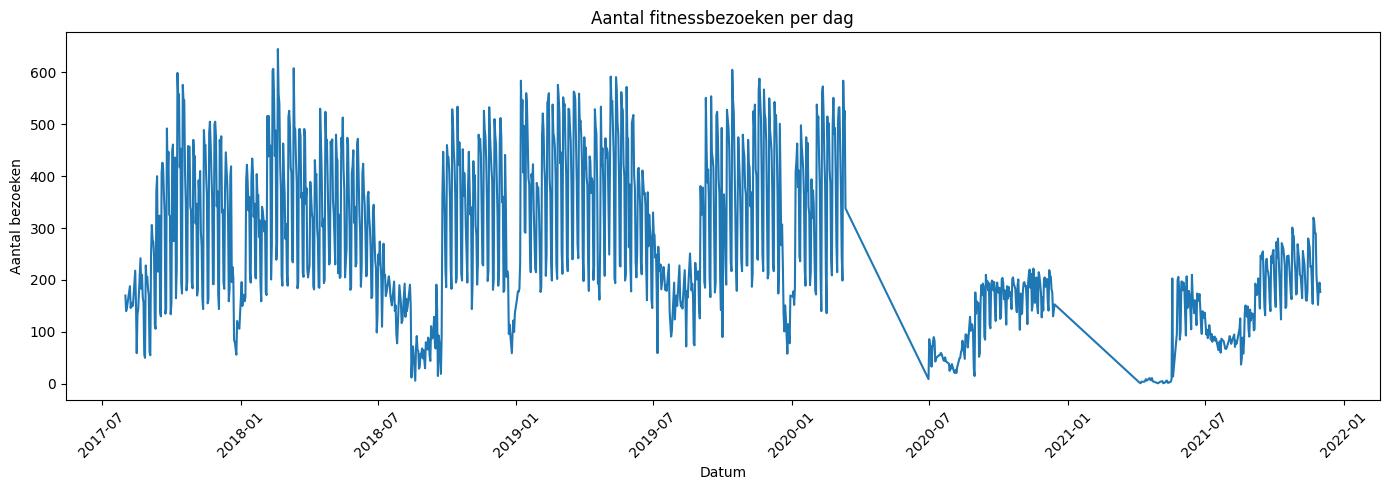

In [104]:
# Basisvisualisaties voor het hoofdstuk Beschrijving van de data / tijdreeksanalyse

# 1. Bezoekers door de tijd
plt.figure(figsize=(14, 5))
plt.plot(df_checkin_per_dag['datum'], df_checkin_per_dag['aantal_bezoeken'])
plt.title('Aantal fitnessbezoeken per dag')
plt.xlabel('Datum')
plt.ylabel('Aantal bezoeken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

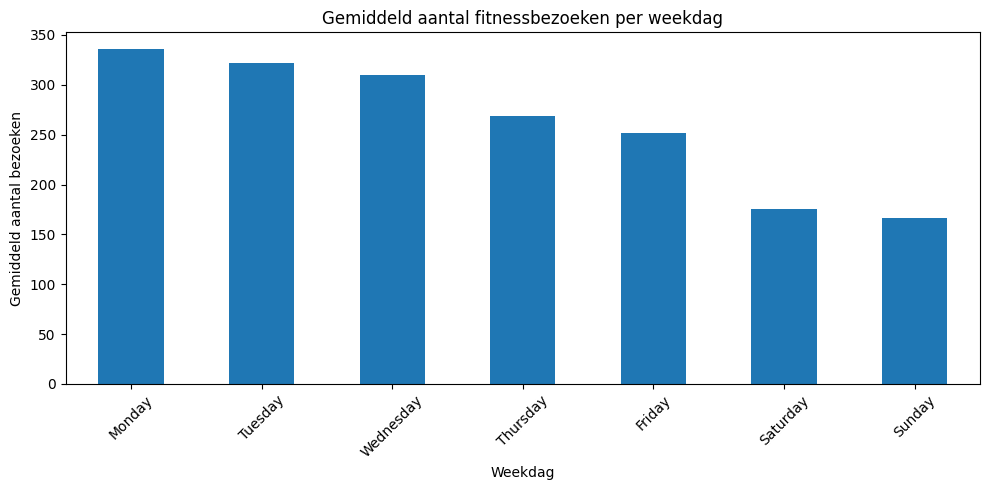

In [105]:
# 2. Gemiddeld aantal bezoekers per weekdag
weekdag_volgorde = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
gemiddelde_per_weekdag = (
    df_checkin_per_dag
    .groupby('weekdag')['aantal_bezoeken']
    .mean()
    .reindex(weekdag_volgorde)
)

plt.figure(figsize=(10, 5))
gemiddelde_per_weekdag.plot(kind='bar')
plt.title('Gemiddeld aantal fitnessbezoeken per weekdag')
plt.xlabel('Weekdag')
plt.ylabel('Gemiddeld aantal bezoeken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

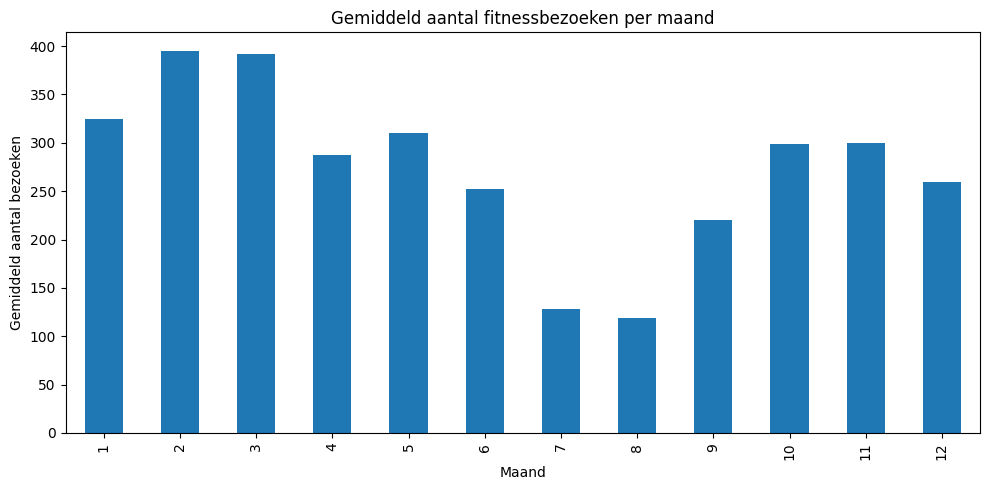

In [106]:
# 3. Gemiddeld aantal bezoekers per maand
gemiddelde_per_maand = df_checkin_per_dag.groupby('maand')['aantal_bezoeken'].mean()

plt.figure(figsize=(10, 5))
gemiddelde_per_maand.plot(kind='bar')
plt.title('Gemiddeld aantal fitnessbezoeken per maand')
plt.xlabel('Maand')
plt.ylabel('Gemiddeld aantal bezoeken')
plt.tight_layout()
plt.show()

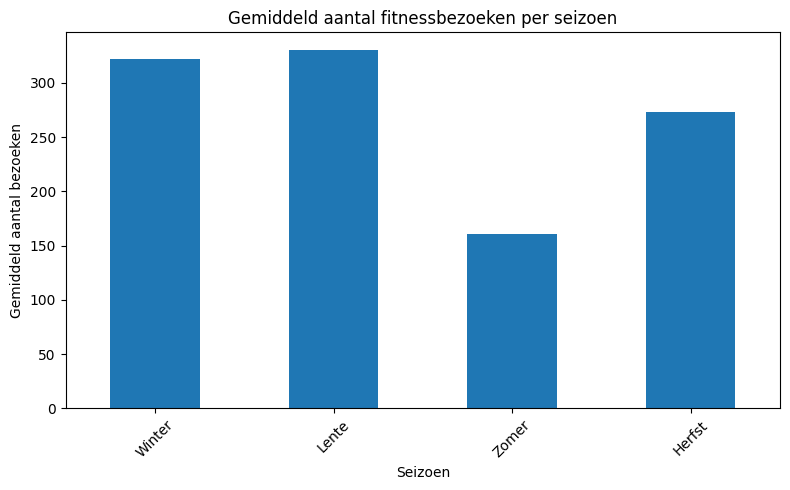

In [107]:
# 4. Gemiddeld aantal bezoekers per seizoen
gemiddelde_per_seizoen = df_checkin_per_dag.groupby('seizoen')['aantal_bezoeken'].mean().reindex(['Winter', 'Lente', 'Zomer', 'Herfst'])

plt.figure(figsize=(8, 5))
gemiddelde_per_seizoen.plot(kind='bar')
plt.title('Gemiddeld aantal fitnessbezoeken per seizoen')
plt.xlabel('Seizoen')
plt.ylabel('Gemiddeld aantal bezoeken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Card holders

In [64]:
# Descriptive statistics -> In dit geval van weinig toegevoegde waarde? 
df_ACLO_card.klant_nr.describe()

count     30210.000000
mean     212011.084972
std       19142.752815
min       30072.000000
25%      202699.250000
50%      217620.000000
75%      225369.750000
max      235614.000000
Name: klant_nr, dtype: float64

In [65]:
df_ACLO_card.geslacht.describe()

count     30210
unique        3
top       Vrouw
freq      16282
Name: geslacht, dtype: object

In [66]:
df_ACLO_card.omschrijving.value_counts(dropna=False)

omschrijving
ACLO Card 2021-2022    16390
ACLO Card 2020-2021    13820
Name: count, dtype: int64

In [67]:
df_Fitness_card.omschrijving.value_counts(dropna=False)

omschrijving
Fitness Card 2021-2022    1364
Fitness Card 2020-2021     969
Name: count, dtype: int64

In [68]:
df_ACLO_card.geslacht.value_counts(dropna=False)

geslacht
Vrouw       16282
Man         13139
Onbekend      789
Name: count, dtype: int64

In [69]:
# ChatGPT prompt: Ik wil van mijn dataframe het aantal mannen en vrouwen tellen per jaar. Hoe laat ik deze aantallen zien in pandas?
df_ACLO_card.groupby(['geldigheid_card', 'geslacht']).size().unstack(fill_value=0)

geslacht,Man,Onbekend,Vrouw
geldigheid_card,,,
2020-2021,6162,202,7456
2021-2022,6977,587,8826


In [70]:
df_Fitness_card.geslacht.value_counts(dropna=False)

geslacht
Man         1627
Vrouw        689
Onbekend      17
Name: count, dtype: int64

In [71]:
df_Fitness_card.groupby(['geldigheid_card', 'geslacht']).size().unstack(fill_value=0)

geslacht,Man,Onbekend,Vrouw
geldigheid_card,,,
2020-2021,676,3,290
2021-2022,951,14,399


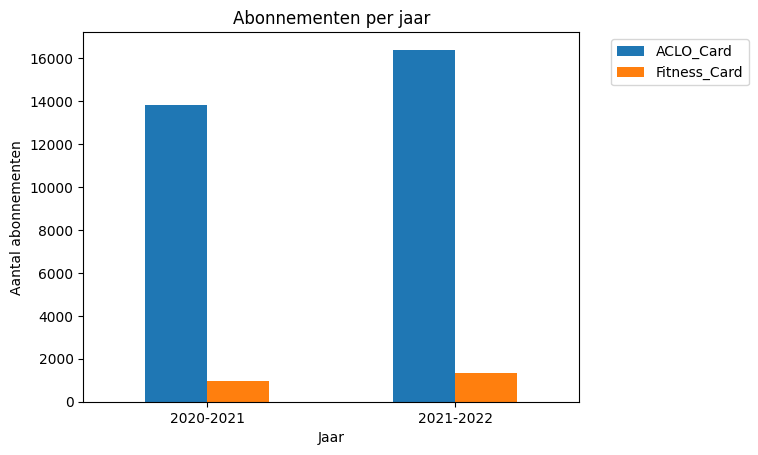

In [72]:
# Aantal ACLO Card houders per seizoen/collegejaar
# Aantal Fitness Card houders per seizoen/collegejaar
# In één overzicht -> grouped bar chart 
# ChatGPT prompt: Ik heb nu een dataframe met daarin alle abonnementen en daarin aangegeven of die klanten een fitness abonnement hebben ja of nee. 
# Nu wil ik een grouped bar chart maken. Hierin wil ik per jaar het aantal abonnementen laten zien, met daarnaast het aantal fitness abonnementen. Hoe doe ik dat in pandas. 
# Vervolgvraag: Kan ik in een plt de legenda ook op een andere plek zetten?

overzicht = (
    df_ACLO_card.groupby('geldigheid_card')
    .agg(
        ACLO_Card=('klant_nr', 'count'),
        Fitness_Card=('fitness_abonnement', lambda x: (x == 'Ja').sum()
        )
    )
)

overzicht.plot(kind='bar')

plt.xlabel('Jaar')
plt.ylabel('Aantal abonnementen')
plt.title('Abonnementen per jaar')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

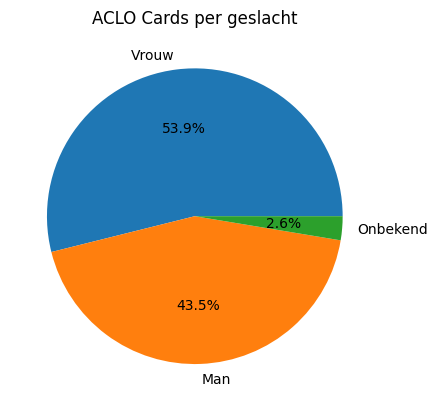

In [73]:
# Man/vrouw verhouding in beide kaartsoorten
df_ACLO_card['geslacht'].value_counts(dropna=False).plot(kind="pie", autopct="%1.1f%%")
plt.title('ACLO Cards per geslacht')
plt.ylabel('')
plt.show()

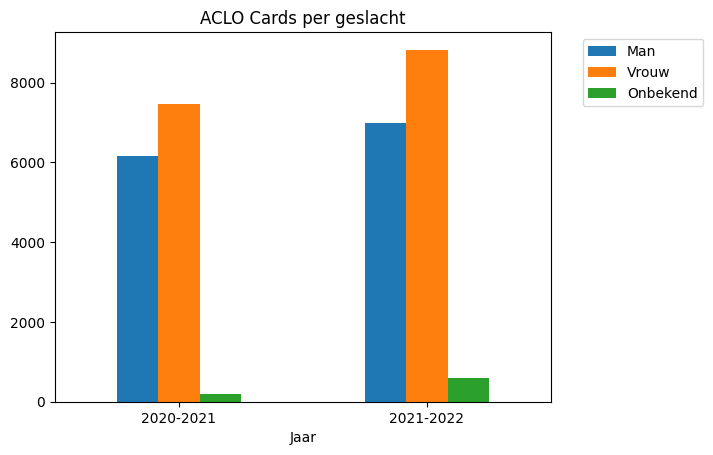

In [74]:
overzicht = (
    df_ACLO_card.groupby('geldigheid_card')
    .agg(
        Man=('geslacht', lambda x: (x == 'Man').sum()),
        Vrouw=('geslacht', lambda x: (x == 'Vrouw').sum()),
        Onbekend=('geslacht', lambda x: (x == 'Onbekend').sum())              
    )
)

overzicht.plot(kind='bar')

plt.xlabel('Jaar')
plt.ylabel('')
plt.title('ACLO Cards per geslacht')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

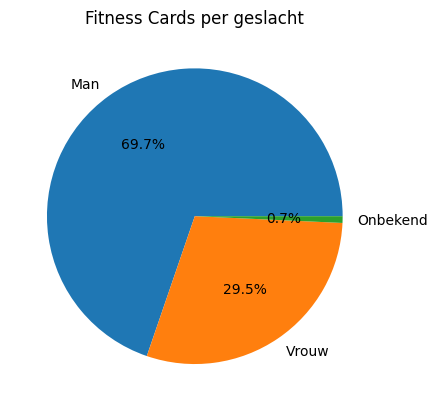

In [75]:
df_Fitness_card['geslacht'].value_counts(dropna=False).plot(kind="pie", autopct="%1.1f%%")
plt.title('Fitness Cards per geslacht')
plt.ylabel('')
plt.show()

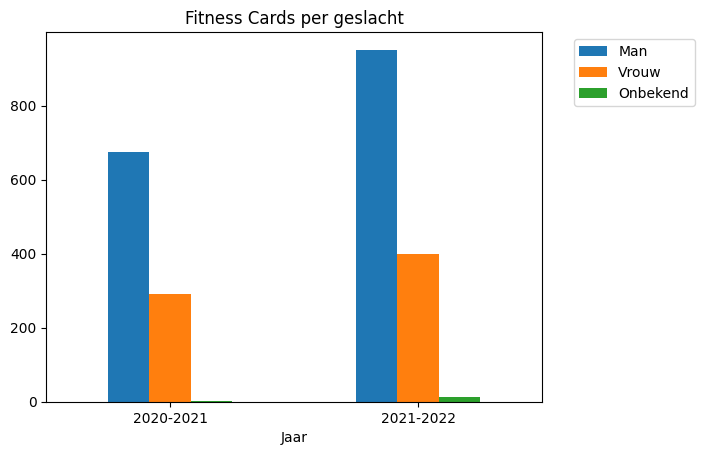

In [76]:
overzicht = (
    df_Fitness_card.groupby('geldigheid_card')
    .agg(
        Man=('geslacht', lambda x: (x == 'Man').sum()),
        Vrouw=('geslacht', lambda x: (x == 'Vrouw').sum()),
        Onbekend=('geslacht', lambda x: (x == 'Onbekend').sum())              
    )
)

overzicht.plot(kind='bar')

plt.xlabel('Jaar')
plt.ylabel('')
plt.title('Fitness Cards per geslacht')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

# Model

## DAG

In [77]:
# Mogelijke verbanden:
# Geslacht heeft invloed op het aantal bezoekers -> meer mannen dan vrouwen in de fitness data
# Er gaan meer studenten dan medewerkers naar de fitness?
# Op bepaalde dagen gaan er meer mensen naar de fitness, in het weekend zijn studenten bij hun ouders, dus dan minder bezoekers
# In de vakanties zijn er minder bezoekers
# In de tentamenweken zijn er minder bezoekers
# In de zomer minder bezoekers dan in de winter? Invloed van het seizoen
# In bepaalde maanden meer of minder bezoekers
# Vanaf een bepaalde datum was het toegestaan dat ACLO card houders op bepaalde dagen toegang hebben tot de fitness. Maar het is nog steeds waarschijnlijker dat fitness card houders meer naar de fitness gaan.
# Datum bepaalt welke maand/dag/week/seizoen het is, of het tentamenperiode is of niet
# Tentamenperiodes hebben wel invloed op bezoeken van studenten, maar niet op dat van medewerkers
# Of het weekend is heeft meer invloed op de bezoeken van studenten dan dat van medewerkers

# Extra:
# Weersinvloeden
# Corona maatregelen


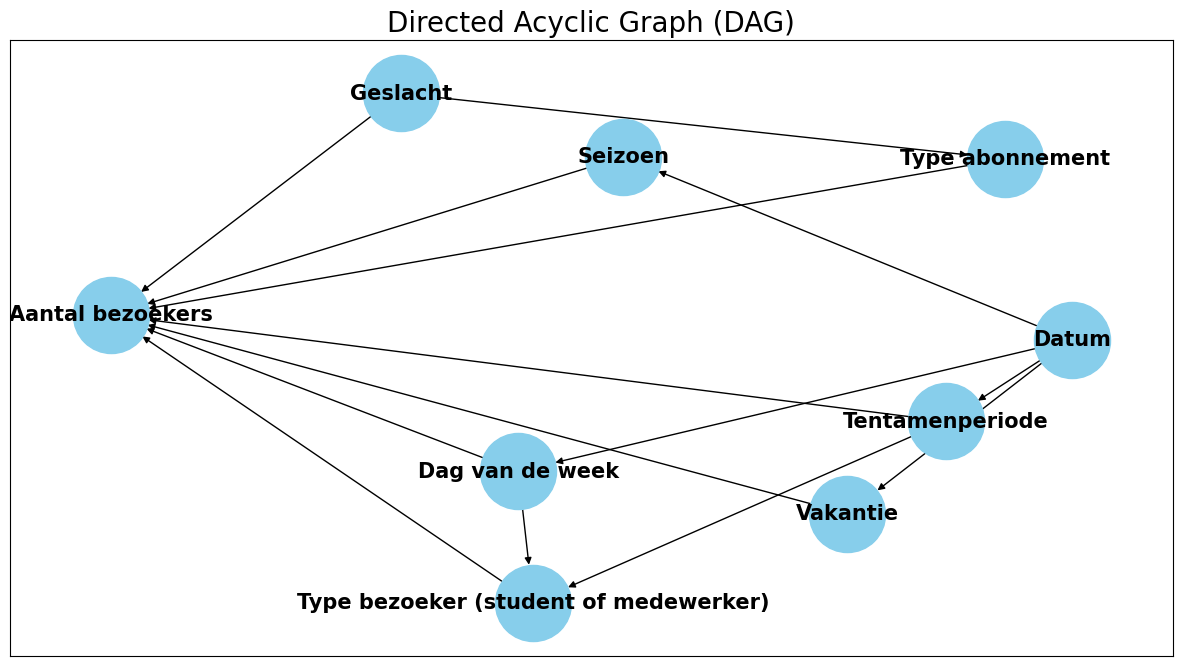

In [78]:
dag = nx.DiGraph()

# Add nodes (features)
# features = ['Datum', 'Dag van de week', 'Seizoen', 'Vakantie', 'Tentamenperiode', 'Klantnummer', 'Type bezoeker (student of medewerker)', 'Geslacht', 'Type abonnement', 'Aantal bezoekers']
features = ['Datum', 'Dag van de week', 'Seizoen', 'Vakantie', 'Tentamenperiode', 'Type bezoeker (student of medewerker)', 'Geslacht', 'Type abonnement', 'Aantal bezoekers']
# features = ['Datum', 'Dag van de week', 'Seizoen', 'Vakantie', 'Tentamenperiode', 'Type bezoeker (student of medewerker)', 'Geslacht', 'Type abonnement', 'Aantal bezoekers', 'Weer', 'Corona (maatregelen)']
dag.add_nodes_from(features)

# Define the relationships between features (edges), put in the edges you identified in the previous cell
# edges = [
#     ('Datum', 'Dag van de week'),
#     ('Datum', 'Seizoen'),
#     ('Datum', 'Vakantie'),
#     ('Datum', 'Tentamenperiode'),
#     ('Dag van de week', 'Type bezoeker (student of medewerker)'),
#     ('Dag van de week', 'Aantal bezoekers'),
#     ('Seizoen', 'Aantal bezoekers'),
#     ('Vakantie', 'Aantal bezoekers'),
#     ('Tentamenperiode', 'Aantal bezoekers'),
#     ('Tentamenperiode', 'Type bezoeker (student of medewerker)'),
#     ('Klantnummer', 'Type bezoeker (student of medewerker)'),
#     ('Klantnummer', 'Geslacht'),
#     ('Klantnummer', 'Type abonnement'),
#     ('Type bezoeker (student of medewerker)', 'Aantal bezoekers'),
#     ('Geslacht', 'Type abonnement'),
#     ('Geslacht', 'Aantal bezoekers'),
#     ('Type abonnement', 'Aantal bezoekers')
# ]

edges = [
    ('Datum', 'Dag van de week'),
    ('Datum', 'Seizoen'),
    ('Datum', 'Vakantie'),
    ('Datum', 'Tentamenperiode'),
    ('Dag van de week', 'Type bezoeker (student of medewerker)'),
    ('Dag van de week', 'Aantal bezoekers'),
    ('Seizoen', 'Aantal bezoekers'),
    ('Vakantie', 'Aantal bezoekers'),
    ('Tentamenperiode', 'Aantal bezoekers'),
    ('Tentamenperiode', 'Type bezoeker (student of medewerker)'),
    ('Type bezoeker (student of medewerker)', 'Aantal bezoekers'),
    ('Geslacht', 'Type abonnement'),
    ('Geslacht', 'Aantal bezoekers'),
    ('Type abonnement', 'Aantal bezoekers')
]

# edges = [
#     ('Datum', 'Dag van de week'),
#     ('Datum', 'Seizoen'),
#     ('Datum', 'Vakantie'),
#     ('Datum', 'Tentamenperiode'),
#     ('Daum', 'Weer'),
#     ('Datum', 'Corona (maatregelen)'),
#     ('Dag van de week', 'Type bezoeker (student of medewerker)'),
#     ('Dag van de week', 'Aantal bezoekers'),
#     ('Seizoen', 'Aantal bezoekers'),
#     ('Vakantie', 'Aantal bezoekers'),
#     ('Tentamenperiode', 'Aantal bezoekers'),
#     ('Tentamenperiode', 'Type bezoeker (student of medewerker)'),
#     ('Type bezoeker (student of medewerker)', 'Aantal bezoekers'),
#     ('Geslacht', 'Type abonnement'),
#     ('Geslacht', 'Aantal bezoekers'),
#     ('Type abonnement', 'Aantal bezoekers')
#     ('Seizoen', 'Weer'),
#     ('Weer', 'Aantal bezoekers'),
#     ('Corona (maatregelen)', 'Aantal bezoekers')
# ]

dag.add_edges_from(edges)

# Visualize the DAG
plt.figure(figsize=(15, 8))
pos = nx.spring_layout(dag)  # Position nodes using Fruchterman-Reingold force-directed algorithm
nx.draw_networkx(dag, pos, with_labels=True, node_size=3000, node_color="skyblue", font_size=15, font_weight='bold', edge_color='black')
plt.title("Directed Acyclic Graph (DAG)", fontsize=20)
plt.show()

## Correlaties 

### Check-in tijden

### Card holders

In [ ]:
# Eigenlijk alleen maar categorische waarden, dus een correlatie matrix zoals in het voorbeeld notebook lukt niet? 
# Code uit het voorbeeld notebook:
# corr = df_ACLO_card.corr()
# corr
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
# plt.title("Correlation Matrix", fontsize=20)    
# plt.show()

# De enige correlatie die nuttig kan zijn is die tussen het hebben van een fitness abonnement en het geslacht.
# https://www.scribbr.nl/statistiek/cramers-v/
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html 
# https://www.geeksforgeeks.org/python/python-pearsons-chi-square-test/

# Kruistabel maken
pd.crosstab(df_ACLO_card['fitness_abonnement'], df_ACLO_card['geslacht'], margins=True)

geslacht,Man,Onbekend,Vrouw,All
fitness_abonnement,,,,
Ja,1613,16,683,2312
Nee,11526,773,15599,27898
All,13139,789,16282,30210


In [92]:
# Chi2 berekenen
stat, p, dof, expected = chi2_contingency(pd.crosstab(df_ACLO_card['fitness_abonnement'], df_ACLO_card['geslacht']))
print("Chi2 Stat:", stat)
print("Degrees of Freedom:", dof)
print("Expected:", expected)

# interpret p-value
# H0: there is no relation between the variables, H1: there is a significant relationship between the two variables
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

Chi2 Stat: 708.2424279840069
Degrees of Freedom: 2
Expected: [[ 1005.54015227    60.38291956  1246.07692817]
 [12133.45984773   728.61708044 15035.92307183]]
p value is 1.611056748288764e-154
Dependent (reject H0)


In [ ]:
# Cramers V berekenen -> Zelfde interpreatie als pearsons R
# Wortel van chi2 gedeeld door n keer het minimum van (aantal rijen - 1) of (aantal kolommen - 1)
# print(len(df_ACLO_card)) 
math.sqrt(stat/(len(df_ACLO_card) * (2-1))) 

0.15311424858893294